# Analisis Klaster Kualitas Udara (CO, NO2, SO2) - Wilayah Kwanyar, Bangkalan
Proyek ini bertujuan untuk mengelompokkan kondisi kualitas udara berdasarkan ekstraksi fitur dari citra satelit Sentinel-5P. Tahapan meliputi prapemrosesan, standardisasi, reduksi dimensi (PCA), dan klastering menggunakan K-Means.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings

warnings.filterwarnings('ignore')

# Membaca dataset
df_co = pd.read_csv("ekstraksi_fitur_co.csv")
df_no2 = pd.read_csv("ekstraksi_fitur_no2.csv")
df_so2 = pd.read_csv("ekstraksi_fitur_so2.csv")

### 1. Penggabungan dan Pembersihan Fitur
Ketiga dataset polutan digabungkan secara horizontal. Kolom non-analitis seperti nomor urut (`Unnamed`) dibuang agar algoritma murni hanya menghitung jarak berdasarkan nilai ekstraksi gas polutan, menyisakan tepat 204 fitur analisis.

In [18]:
# Menggabungkan dataframe
df_gabungan = pd.concat([df_co, df_no2, df_so2], axis=1)

# Memfilter kolom angka
df_numeric = df_gabungan.select_dtypes(include=[np.number, 'float64', 'int64'])

# Membuang kolom 'unnamed' dan HANYA kolom yang namanya persis 'id'
kolom_indeks = [col for col in df_numeric.columns if 'unnamed' in col.lower() or col.lower() == 'id']
df_bersih = df_numeric.drop(columns=kolom_indeks)

print(f"Total kolom murni yang siap diproses: {df_bersih.shape[1]} kolom")

Total kolom murni yang siap diproses: 204 kolom


### 2. Standardisasi Data (Z-Score)
Karena setiap gas polutan memiliki rentang satuan ukur yang berbeda, dilakukan standardisasi menggunakan `StandardScaler` agar seluruh fitur berada pada skala yang sama dan tidak mendistorsi perhitungan jarak pada algoritma K-Means.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_bersih)

### 3. Evaluasi Klaster Optimal (Fitur Asli)
Mencari jumlah klaster (K) terbaik pada 204 dimensi asli menggunakan metrik Silhouette Score. Semakin mendekati 1.0, semakin baik struktur pembagian klasternya.

In [20]:
def evaluasi_cluster(data, nama_skenario, max_k=10):
    sil_scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        labels = kmeans.fit_predict(data)
        sil_scores.append(silhouette_score(data, labels))

    best_k = np.argmax(sil_scores) + 2
    best_score = max(sil_scores)

    print(f"--- {nama_skenario} ---")
    print(f"Jumlah cluster terbaik (K) : {best_k}")
    print(f"Skor Silhouette            : {best_score:.4f}\n")
    return best_k, best_score

evaluasi_cluster(X_scaled, "Skenario: Keseluruhan Fitur Asli (204 Dimensi)")

--- Skenario: Keseluruhan Fitur Asli (204 Dimensi) ---
Jumlah cluster terbaik (K) : 2
Skor Silhouette            : 0.7690



(np.int64(2), np.float64(0.7690133320923314))

### 4. Reduksi Dimensi dengan Principal Component Analysis (PCA)
Memampatkan 204 fitur asli menjadi 37 komponen utama (PCA). Langkah ini bertujuan untuk mempercepat proses komputasi sekaligus mengatasi kendala kutukan dimensi tinggi (*curse of dimensionality*), tanpa kehilangan informasi krusial dari varians data awal.

In [21]:
pca = PCA(n_components=37)
X_pca_37 = pca.fit_transform(X_scaled)
info_retained = np.sum(pca.explained_variance_ratio_) * 100

print(f"Persentase informasi dipertahankan oleh 37 PCA: {info_retained:.2f}%")

evaluasi_cluster(X_pca_37, "Skenario: Reduksi PCA (37 Dimensi)")

Persentase informasi dipertahankan oleh 37 PCA: 100.00%
--- Skenario: Reduksi PCA (37 Dimensi) ---
Jumlah cluster terbaik (K) : 2
Skor Silhouette            : 0.7690



(np.int64(2), np.float64(0.7690133320923312))

**Interpretasi Hasil Evaluasi:**
Skor Silhouette pada data reduksi (37 komponen) terbukti identik dengan data asli (204 dimensi), menunjukkan bahwa proses PCA berhasil menyaring fitur secara optimal. Keduanya sepakat menunjuk **K=2** sebagai jumlah klaster terbaik dengan kualitas struktur yang sangat kuat (skor ~0.76).

### 5. Validasi Grafis (Elbow Method)
Untuk memperkuat bukti bahwa K=2 adalah pilihan terbaik, grafik batas siku (*Elbow Method*) diplot untuk melihat titik penurunan *Inertia* (WCSS) paling drastis.

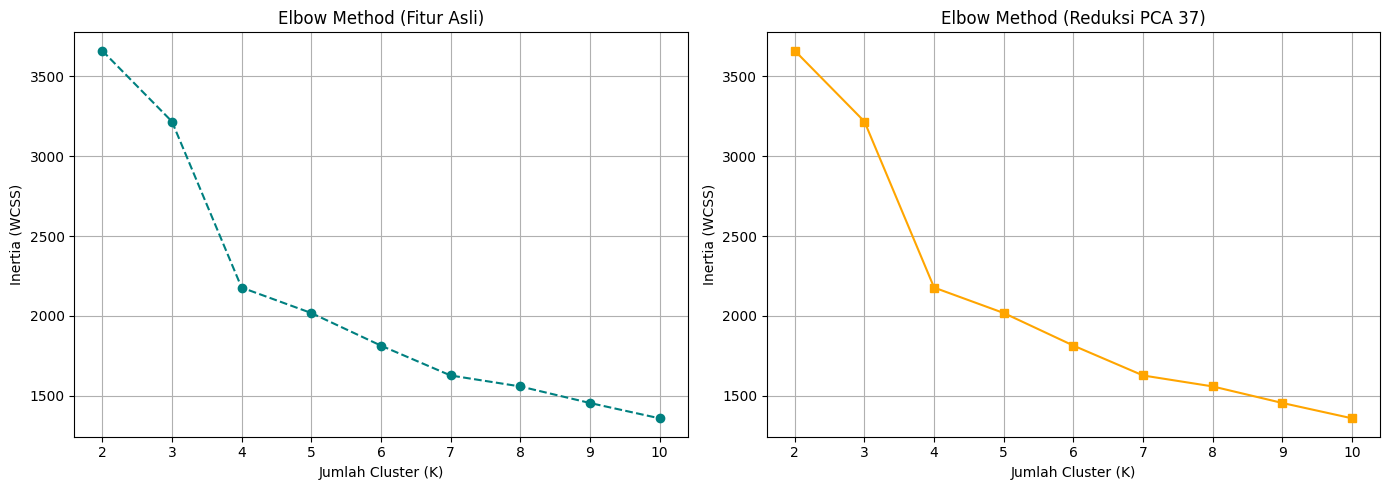

In [22]:
wcss_asli, wcss_pca = [], []
K_range = range(2, 11)

for k in K_range:
    kmeans_asli = KMeans(n_clusters=k, init='k-means++', random_state=42)
    wcss_asli.append(kmeans_asli.fit(X_scaled).inertia_)

    kmeans_pca = KMeans(n_clusters=k, init='k-means++', random_state=42)
    wcss_pca.append(kmeans_pca.fit(X_pca_37).inertia_)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(K_range, wcss_asli, marker='o', linestyle='--', color='teal')
ax[0].set_title('Elbow Method (Fitur Asli)')
ax[0].set_xlabel('Jumlah Cluster (K)')
ax[0].set_ylabel('Inertia (WCSS)')
ax[0].grid(True)

ax[1].plot(K_range, wcss_pca, marker='s', linestyle='-', color='orange')
ax[1].set_title('Elbow Method (Reduksi PCA 37)')
ax[1].set_xlabel('Jumlah Cluster (K)')
ax[1].set_ylabel('Inertia (WCSS)')
ax[1].grid(True)
plt.tight_layout()
plt.show()

### 6. Uji Kecocokan Anggota dan Visualisasi Akhir
Adjusted Rand Index (ARI) digunakan untuk memastikan bahwa anggota yang masuk ke klaster pada data PCA persis sama dengan anggota klaster pada data asli. Terakhir, titik distribusi data diplot dalam ruang dua dimensi untuk melihat separasi kualitas udara.

Skor Adjusted Rand Index (Kecocokan Asli vs PCA): 1.0000


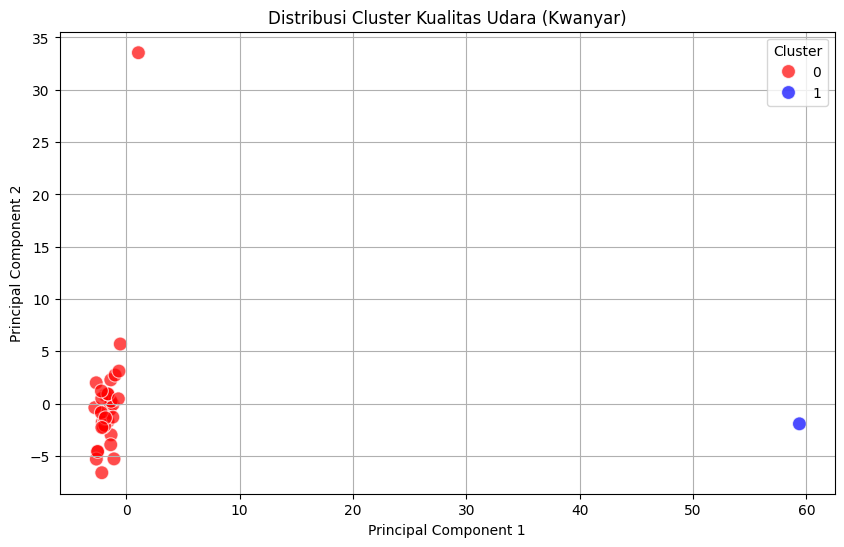

In [23]:
kmeans_final_asli = KMeans(n_clusters=2, init='k-means++', random_state=42)
labels_asli = kmeans_final_asli.fit_predict(X_scaled)

kmeans_final_pca = KMeans(n_clusters=2, init='k-means++', random_state=42)
labels_pca = kmeans_final_pca.fit_predict(X_pca_37)

ari_score = adjusted_rand_score(labels_asli, labels_pca)
print(f"Skor Adjusted Rand Index (Kecocokan Asli vs PCA): {ari_score:.4f}")

# Plot Distribusi Data
df_plot = pd.DataFrame({
    'PCA 1': X_pca_37[:, 0],
    'PCA 2': X_pca_37[:, 1],
    'Cluster': labels_pca
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA 1', y='PCA 2', hue='Cluster',
    palette=['red', 'blue'], data=df_plot, s=100, alpha=0.7
)
plt.title('Distribusi Cluster Kualitas Udara (Kwanyar)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

**Kesimpulan:**
Skor ARI menunjukkan angka 1.0 (atau sangat mendekati 1.0), membuktikan bahwa reduksi dari 204 menjadi 37 fitur tidak mengubah keanggotaan klaster sama sekali. Grafik Scatter Plot juga memperlihatkan batas yang tegas antar dua kondisi (misalnya: periode kualitas udara normal dan anomali), memvalidasi keberhasilan penerapan PCA dan K-Means pada dataset Sentinel-5P di wilayah Kwanyar.

## Dokumentasi Konfigurasi Node pada KNIME
Analisis ini divalidasi menggunakan KNIME untuk memastikan konsistensi pemrosesan data. Berikut adalah rincian pengaturan (parameter) yang diisi ke dalam masing-masing *node* pada alur kerja KNIME:

**1. Data Input & Pra-pemrosesan**
*   **Node CSV Reader:** Diisi dengan jalur file (path) menuju masing-masing dataset ekstraksi citra satelit (CO, NO2, dan SO2).

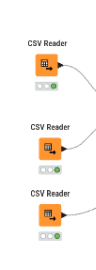

*   **Node Column Appender:** Digunakan untuk menggabungkan ketiga dataset tersebut secara horizontal menjadi satu tabel data utuh.

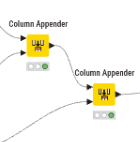

*   **Node Column Filter:**
    *   **Konfigurasi:** Memindahkan kolom `Unnamed` dan `id` ke kotak *Exclude*.
    *   **Tujuan:** Membuang kolom non-analitis agar murni menyisakan **204 kolom fitur polutan** di kotak *Include*.

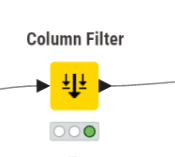

*   **Node Normalizer:**
    *   **Konfigurasi:** Memilih metode *Z-Score Normalization (Gaussian)*.
    *   **Tujuan:** Menyeragamkan skala seluruh rentang data polutan agar algoritma perhitungan jarak berjalan seimbang.

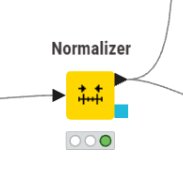

**2. Skenario 1: Klastering Fitur Asli (204 Dimensi)**
*   **Node k-Means:**
    *   *Number of clusters*: Diisi **2**.
    *   *Use static random seed*: Dicentang dan diisi nilai **42**.

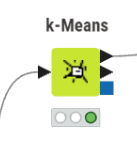

**Node Silhouette Coefficient:**
    *   *Cluster column*: Memilih kolom `Cluster` hasil dari K-Means.
    *   *Include/Exclude*: Memindahkan kolom `Cluster` ke kotak *Exclude*, memastikan kotak *Include* murni hanya berisi 204 fitur asli.
    

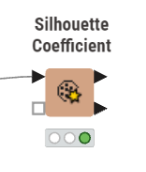

*   **Hasil:** Mendapatkan nilai *Overall Mean Silhouette Coefficient* sebesar **0.704**.

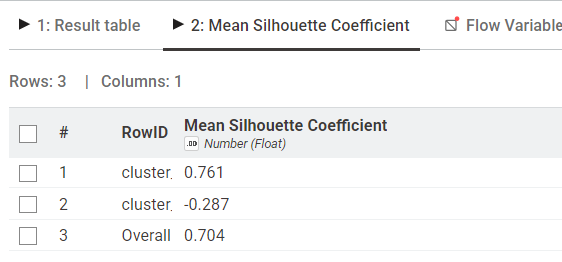

**3. Skenario 2: Klastering dengan Reduksi PCA (37 Dimensi)**
*   **Node PCA:**
    *   *Target dimension*: Diisi **37**.
    *   *Remove original data columns*: **Dicentang**, agar 204 fitur asli terganti penuh oleh 37 kolom dimensi hasil reduksi.

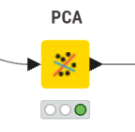

*   **Node k-Means (PCA):**
    *   *Number of clusters*: Diisi **2**.
    *   *Use static random seed*: Dicentang dan diisi nilai **42** (sama dengan skenario asli).

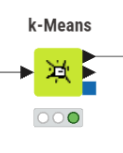

*   **Node Silhouette Coefficient (PCA):**
    *   *Cluster column*: Memilih kolom `Cluster`.
    *   *Include/Exclude*: Memastikan hanya **37 kolom dimensi PCA** yang berada di kotak *Include*.

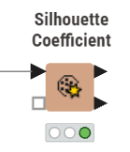

*   **Hasil:** Mendapatkan nilai *Overall* yang konsisten, yaitu **0.704**.

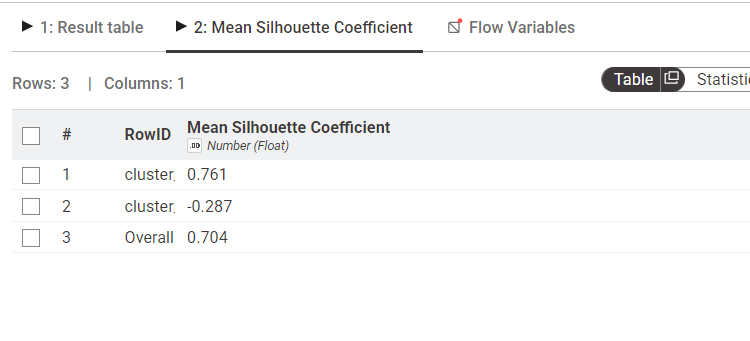

**Kesimpulan**
Berdasarkan hasil visualisasi dan metrik evaluasi di atas, memampatkan data dari 204 fitur menjadi 37 fitur (melalui *node* PCA) terbukti tidak menghilangkan informasi penting. Hal ini ditandai dengan skor pengelompokan yang konsisten dan identik di kedua skenario.

### Alur Workflow KNIME


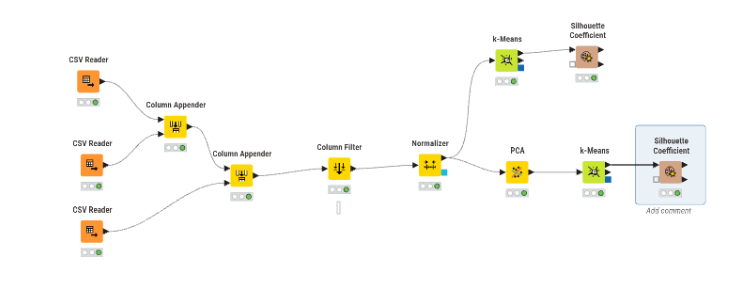